📘 Regression Models in Practice: Betelgeuse Brightness

**Welcome**

This notebook builds directly on the concepts from the video and reading:

**Supervised learning**

**Regression as continuous prediction**

Features (X) and target (y)

Training vs testing

Different regression model types

Model evaluation (MSE and R²)

You will not see heavy maths here.
Instead, you will see the same ideas applied step by step to real astronomical data.

**How to use this notebook**

Read the explanation cells carefully

Run each code cell using Shift + Enter

Follow the notebook from top to bottom

Focus on why each step exists, not just the result

```
# This is formatted as code
```



1️⃣ **The problem we are solving**

We are studying Betelgeuse, a variable star whose brightness changes over time.

For each observation, we record:

Time (e.g. day number)

Brightness

Our goal:

Predict brightness from time

This is a regression problem because brightness is a continuous number, not a category.

2️⃣ Loading the Betelgeuse dataset

For simplicity, we’ll use a small, clean dataset.

✅ Run the code cell below.

In [ ]:
import pandas as pd

data = pd.DataFrame({
    "Day": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Brightness": [0.92, 0.95, 0.93, 0.90, 0.88, 0.89, 0.91, 0.94, 0.96, 0.97]
})

data

,Day,Brightness
0,1,0.92
1,2,0.95
2,3,0.93
3,4,0.90
4,5,0.88
5,6,0.89
6,7,0.91
7,8,0.94
8,9,0.96
9,10,0.97


**Explanation**

Each row is one observation in time

Day is our feature (X)

Brightness is our target (y)

Because time has an order, this dataset will later help us understand time-series regression.

3️⃣** Visualising the data**

Before modelling anything, always look at the data.

✅ Run the code cell below.

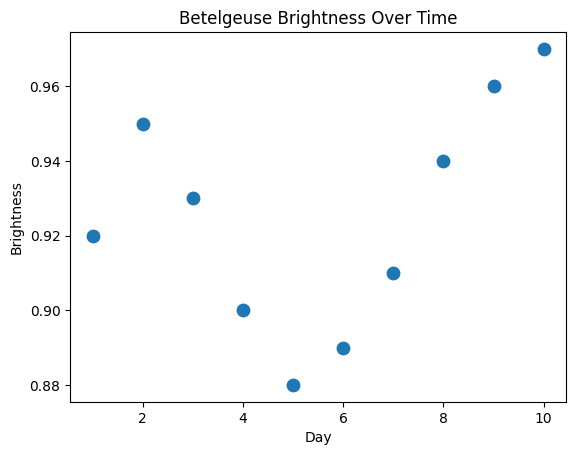

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(data["Day"], data["Brightness"], s=80)
plt.xlabel("Day")
plt.ylabel("Brightness")
plt.title("Betelgeuse Brightness Over Time")
plt.show()

**Explanation**

Each dot is one observation

Brightness changes smoothly over time

The pattern is not perfectly straight

This tells us:

Linear regression might work

But more flexible models may help

4️⃣ **Features (X) and Target (y)**

From the reading:

Features $(X)$→ inputs used to make predictions

Target $(y)$ → the value we want to predict


ŷ = predicted brightness

In code:

In [ ]:
X = data[["Day"]]     # Feature
y = data["Brightness"]  # Target

5️⃣ Training vs Testing: why we split the data

We must not test the model on data it already studied.

This would be like giving a student the exam answers in advance.

✅ Run the code cell below.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

len(X_train), len(X_test)


(7, 3)

**Explanation**

Training set → the model learns patterns here

Test set → unseen data used to check generalisation

If performance is good on the test set, we can trust the model.

6️⃣ Linear Regression: a straight-line model

Linear regression assumes the relationship looks like a straight line.

Train the model

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


LinearRegression()

Make predictions

In [ ]:
y_pred_linear = linear_model.predict(X_test)


7️⃣ Evaluating the linear model (MSE and R²)

From the reading:

MSE → average size of prediction errors (lower is better)

R² → how much variation the model explains (closer to 1 is better)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

mse_linear, r2_linear


(0.0012281050877364903, -0.2852262546079569)

Interpretation

These numbers tell us how good the fit really is

Visuals help, but metrics decide

8️⃣ Polynomial Regression: allowing curves

What if the relationship is not a straight line?

Polynomial regression adds powers like
𝑋
2
X
2
,
𝑋
3
X
3
, etc.

This gives the model flexibility.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)


**Evaluate the polynomial model**

In [ ]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

mse_poly, r2_poly


(0.0005466132838184173, 0.4279628425156089)

**Key idea**

Polynomial models can fit curves better

But too much flexibility can overfit

The test set tells the truth

| Model      | MSE               | R²                    |
| ---------- | ----------------- | --------------------- |
| Linear     | Smaller is better | Closer to 1 is better |
| Polynomial | Compare carefully | Watch for overfitting |

🔟 Time-Series Regression: when order matters

This dataset is special because:

Time has meaning

Yesterday affects today.

This is the core idea of time-series regression.

**Key characteristics:**

Data points are ordered

We must be careful not to shuffle randomly

The past influences the future

**For now, remember:**

When data evolves over time, time-series methods are required.

1️⃣1️⃣ **Final takeaway**

You have now seen:

Regression predicts continuous values

Data is split into training and testing sets

Linear models assume straight lines

Polynomial models allow curves

Time-series data requires special care

MSE and R² tell us how good a model really is

This notebook completes the full regression pipeline described in the video and reading.